# Функция визуализации (универсальная)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_svm_boundary(model, X, y, title="SVM Classification Result"):
    """
    Визуализирует границу решения SVM, опорные векторы и отступы.
    Поддерживает:
    1) Двойственные SVM (с атрибутами lambdas, K, support_vectors)
    2) SGD SVM (с атрибутами w, b)
    
    Параметры:
    model : обученная модель (SVM_Lagrangian или SOFT_SVM_SGD)
    X : признаки (n_samples, 2)
    y : истинные метки (0 или 1)
    title : заголовок графика
    """
    # Определяем тип модели по наличию атрибутов
    is_dual = hasattr(model, 'lambdas')  # двойственная SVM (с λ, K, опорными векторами)
    is_sgd = hasattr(model, 'w') and hasattr(model, 'b')  # SGD SVM
    
    # Создаём цветовую карту для точек
    colors = {0: 'blue', 1: 'red'}
    y_colors = [colors[yi] for yi in y]
    
    # Определяем границы графика с отступом
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Создаём сетку для contour
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    plt.figure(figsize=(10, 8))
    
    # ----- ВЫЧИСЛЯЕМ ПРЕДСКАЗАНИЯ ДЛЯ ФОНА -----
    if is_dual:
        # Двойственная SVM: используем predict
        Z_pred = model.predict(grid_points).reshape(xx.shape)
        # Для контуров: если есть decision_function, используем её
        if hasattr(model, 'decision_function'):
            Z_decision = model.decision_function(grid_points).reshape(xx.shape)
        else:
            # Если нет decision_function, используем разность предсказаний
            Z_decision = Z_pred.astype(float) * 2 - 1  # примерная аппроксимация
    elif is_sgd:
        # SGD SVM: линейная модель
        decision_values = grid_points @ model.w + model.b
        Z_pred = (decision_values >= 0).astype(int).reshape(xx.shape)
        Z_decision = decision_values.reshape(xx.shape)
    else:
        raise TypeError("Model not recognized: missing 'lambdas' or ('w' and 'b') attributes")
    
    # ----- 1. ЦВЕТОВОЙ ФОН (области предсказаний) -----
    background_cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])
    plt.contourf(xx, yy, Z_pred, alpha=0.3, cmap=background_cmap, levels=[-0.5, 0.5, 1.5])
    
    # ----- 2. ГРАНИЦЫ: разделяющая линия (0) и отступы (±1) -----
    if is_dual:
        # Для двойственной SVM: рисуем отступы ±1, если есть decision_function
        if hasattr(model, 'decision_function'):
            plt.contour(xx, yy, Z_decision, colors='black', levels=[-1, 0, 1], 
                        linestyles=['--', '-', '--'], linewidths=2)
        else:
            # Только разделяющая линия (0)
            plt.contour(xx, yy, Z_decision, colors='black', levels=[0], 
                        linestyles=['-'], linewidths=2)
    elif is_sgd:
        # Для SGD SVM: только разделяющая линия (0), отступы не определены
        plt.contour(xx, yy, Z_decision, colors='black', levels=[0], 
                    linestyles=['-'], linewidths=2)  # <-- убрали label
    
    # ----- 3. ОПОРНЫЕ ВЕКТОРЫ (только для двойственной SVM) -----
    if is_dual:
        if hasattr(model, 'support_vectors'):
            sv_mask = model.support_vectors
            sv_points = X[sv_mask]
        elif hasattr(model, 'lambdas') and hasattr(model, 'tol'):
            sv_mask = model.lambdas > model.tol
            sv_points = X[sv_mask]
        else:
            sv_points = np.empty((0, 2))
        
        if len(sv_points) > 0:
            plt.scatter(sv_points[:, 0], sv_points[:, 1], 
                        s=150, facecolors='none', edgecolors='yellow', linewidths=2.5,
                        label='Support Vectors')
    
    # ----- 4. ТОЧКИ ДАННЫХ -----
    plt.scatter(X[:, 0], X[:, 1], c=y_colors, s=40, alpha=0.8, edgecolors='k', linewidth=0.5)
    
    # ----- ОФОРМЛЕНИЕ -----
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    
    # Легенда
    legend_elements = []
    legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=2, label='Decision boundary'))
    if is_dual and hasattr(model, 'decision_function'):
        legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Margins (±1)'))
    if is_dual and len(sv_points) > 0:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='yellow', linewidth=0, markerfacecolor='none', markersize=12, label='Support Vectors'))
    
    plt.legend(handles=legend_elements, loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()


# Пример использования для SGD SVM:
# from YOUR_SGD_FILE import SOFT_SVM_SGD
# sgd_svm = SOFT_SVM_SGD(C=1.0, learning_rate=0.01, max_iterations=1000)
# sgd_svm.fit(X_train, y_train)
# plot_svm_boundary(sgd_svm, X_test, y_test, "SGD SVM Classification")

# Пример использования для двойственной SVM:
# lag_svm = SVMLagrangianSMO(kernel='linear', C=1.0)
# lag_svm.fit(X_train, y_train)
# plot_svm_boundary(lag_svm, X_test, y_test, "Lagrangian SVM")

# Реализация Soft SVC

In [ ]:
import numpy as np
class SOFT_SVM():
    def __init__(self, C=1,learning_rate=0.01, tolerance=1e-12, max_iterations=1000):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.C = C
    def fit(self, x_train, y_train):
        n_samples, n_features = x_train.shape
        y_train = np.where(y_train == 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0
        #prev_db = 0
        #prev_dw = np.zeros(n_features)
        prev_loss = np.inf
        hinge_loss_history = []
        for i in range(self.max_iterations):
        #while True:
            func_g = 1 - y_train * (x_train @ self.w + self.b)
            
            hinge_loss = np.maximum(0, func_g).sum()
            loss = 0.5 * np.linalg.norm(self.w)**2 + self.C * hinge_loss
            hinge_loss_history.append(loss)
            
            #производная по регуляризатору
            dw1 = self.w.copy()
            margin_fine = (np.maximum(func_g, 0) > 0).astype(float)
            dw2 = x_train.T @ (self.C * y_train * margin_fine)
            
            dw = dw1 - dw2
            db = self.C * np.sum(y_train * margin_fine) 
            
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            """if np.abs(prev_db - db) < self.tolerance and np.all(np.abs(prev_dw - dw) < self.tolerance):
                print(f"Сошлись на итерации {i}")
                break

            prev_dw=dw
            prev_db=db"""

            if np.abs(prev_loss - loss) < self.tolerance:
                print(f"Сошлись на итерации {i}")
                break

            prev_loss=loss

        return hinge_loss_history

    def predict(self, x_test):
        return np.where(x_test @ self.w + self.b >= 0, 1, 0)

    def score(self, x_test, y_test):
        predictions = self.predict(x_test)
        return np.mean(predictions == y_test)*100

# Реализация Soft Mini-Batch SVC

In [37]:
import numpy as np
class MINI_BATCH_SVM():
    
    def __init__(self, C=1,learning_rate=0.1, tolerance=1e-12, max_iterations=10000, batch_size=32):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.C = C
        self.batch_size = batch_size
        
    def fit(self, x_train, y_train):
        n_samples, n_features = x_train.shape
        y_train = np.where(y_train == 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0
        prev_db = 0
        prev_dw = np.zeros(n_features)
        for i in range(self.max_iterations):
            indices = np.random.permutation(n_samples)
            x_shuffled = x_train[indices]
            y_shuffled = y_train[indices]
            
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                x_batch = x_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                
                func_g = 1 - y_batch * (x_batch @ self.w + self.b)
                margin_fine = (func_g > 0).astype(float)
                
                dw = self.w - self.C * (x_batch.T @ (y_batch * margin_fine))
                db = self.C * np.sum(y_batch * margin_fine)
                
                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            if np.abs(prev_db - db) < self.tolerance and np.all(np.abs(prev_dw - dw) < self.tolerance):
                print(f"сошлись на итерации {i}")
                break

            prev_dw=dw
            prev_db=db

    def predict(self, x_test):
        return np.where(x_test @ self.w + self.b >= 0, 1, 0)

    def score(self, x_test, y_test):
        predictions = self.predict(x_test)
        return np.mean(predictions == y_test) * 100

# Реализация Soft SGD SVC

In [12]:
import numpy as np
class SOFT_SVM_SGD():
    
    def __init__(self, C=1,learning_rate=0.1, tolerance=1e-12, max_iterations=10000):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.C = C
        
    def fit(self, x_train, y_train):
        n_samples, n_features = x_train.shape
        y_train = np.where(y_train == 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0
        prev_db = 0
        prev_dw = np.zeros(n_features)
        hinge_loss_history = []
        for iterat in range(self.max_iterations):
        #while True:
            indices = np.random.permutation(n_samples)
            X_shuffled = x_train[indices]
            y_shuffled = y_train[indices]
            
            for i in range(n_samples):
                xi = X_shuffled[i]
                yi = y_shuffled[i]
            
                func_g = 1 - yi * (xi @ self.w + self.b)

                #Субградиент для Hinge loss
                dw1 = self.w.copy()
                margin_fine = (np.maximum(func_g, 0) > 0).astype(float)  
                dw2 = xi * self.C * yi * margin_fine
                    
                dw = dw1 - dw2
                db = -self.C * yi * margin_fine  #- под вопросом

                lr = self.learning_rate / (1 + 0.001 * i)
                self.w -= lr * dw
                self.b -= lr * db

                if np.abs(prev_db - db) < self.tolerance and np.all(np.abs(prev_dw - dw) < self.tolerance):
                    print(f"Сошлись на итерации {iterat}")
                    break

                prev_dw=dw
                prev_db=db

            hinge_loss = np.maximum(0, 1 - y_train * (x_train @ self.w + self.b)).sum()
            loss = 0.5 * np.linalg.norm(self.w)**2 + self.C * hinge_loss
            hinge_loss_history.append(loss)

        return hinge_loss_history

    def predict(self, x_test):
        return np.where(x_test @ self.w + self.b >= 0, 1, 0)

    def score(self, x_test, y_test):
        predictions = self.predict(x_test)
        return np.mean(predictions == y_test) * 100

# Тесты всех Soft SVC

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Генерируем 200 образцов, 2 признака (для легкой визуализации)
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Преобразуем метки из {0,1} в {-1,1} для SVM
#y = np.where(y == 0, -1, 1)

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
svm = SOFT_SVM_SGD(C=1, learning_rate=0.001, max_iterations=50000)
loss_history=svm.fit(X_train, y_train)
print(f"w = {svm.w}")
print(f"b = {svm.b}")
res = svm.predict(X_test)
print(svm.score(X_train, y_train))
print(svm.score(X_test, y_test))
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, res) * 100)

import matplotlib.pyplot as plt

"""def plot_data(X, y, title="Generated Dataset"):
    plt.figure(figsize=(4, 3))
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], 
                color='red', label='Класс -1', alpha=0.7)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], 
                color='blue', label='Класс 1', alpha=0.7)
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация training set
plot_data(X_train, y_train, f"Training Set ({len(X_train)} samples)")

# Визуализация test set
plot_data(X_test, y_test, f"Test Set ({len(X_test)} samples)")
"""
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(4, 3))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='-1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='1')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary')
    plt.legend()
    plt.show()

# Рисуем границу на тренировочных данных
plot_decision_boundary(svm, X_train, y_train)
plot_decision_boundary(svm, X_test, y_test)

plt.figure(figsize=(12, 5))

# График показывает, как последовательность Loss с течением итераций 
#приближается к своему пределу (или не приближается),
#и позволяет диагностировать проблемы со скоростью и устойчивостью сходимости.
plt.plot(loss_history, alpha=0.6, label='Raw Loss', color='blue', linewidth=0.8)

# Скользящее среднее (окно = 10% от длины истории)
window = max(1, len(loss_history) // 10)
smooth = np.convolve(loss_history, np.ones(window)/window, mode='valid')
plt.plot(smooth, label=f'Скользящее среднее (окно={window})', color='red', linewidth=2)

plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость градиентного спуска')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # логарифмическая шкала часто полезная для Loss
plt.tight_layout()
plt.show()
print(f"weights: {svm.w/svm.w.sum()}")  
print(f"bias: {svm.b}")  
# ПОИСК ЛУЧШИХ ПАРАМЕТРОВ
best_acc = 0
best_acc_train = 0
best_params_train = {}
best_params = {}

"""for C in [1, 0.5, 0.1, 0.01, 0.001]:
    for lr in [1e-7,1e-5, 0.001, 0.01, 0.1]:
        for iterations in [1000, 2000, 5000, 10000, 50000]:
            svm = SOFT_SVM_SGD(C=C, learning_rate=lr, max_iterations=iterations)
            svm.fit(X_train, y_train)
            
            acc = svm.score(X_test,y_test)
            acc_train = svm.score(X_train,y_train)

            if acc_train > best_acc_train and acc > best_acc:
                best_acc = acc
                best_acc_train = acc_train
                best_params_train = {'C': C, 'learning_rate': lr, 'iterations': iterations}
            
            print(f"C={C}, lr={lr}, iter={iterations}: {acc:.4f}, {acc_train:.4f}")

print(f"\nЛучший результат на тренировочном: {best_acc_train:.4f}")
print(f"Лучшие параметры на тренировочном: {best_params_train}")
print(f"Лучший результат: {best_acc:.4f}")"""

# Реализация алгоритма SMO для SVC с Хабра в 30 строк 

In [2]:
import numpy as np

class SVM:
  def __init__(self, kernel='linear', C=10000.0, max_iter=100000, degree=3, gamma=1, tol=1e-7):
    self.kernel = {'poly'  : lambda x,y: np.dot(x, y.T)**degree,
         'rbf': lambda x,y: np.exp(-gamma*np.sum((y-x[:,np.newaxis])**2,axis=-1)),
         'linear': lambda x,y: np.dot(x, y.T)}[kernel]
    self.C = C
    self.max_iter = max_iter
    self.tol=tol

  # ограничение параметра t, чтобы новые лямбды не покидали границ квадрата
  def restrict_to_square(self, t, v0, u): 
    t = (np.clip(v0 + t*u, 0, self.C) - v0)[1]/u[1]
    return (np.clip(v0 + t*u, 0, self.C) - v0)[0]/u[0]

  def fit(self, X, y):
    self.X = X.copy()
    # преобразование классов 0,1 в -1,+1; для лучшей совместимости с sklearn
    self.y = y * 2 - 1 
    self.lambdas = np.zeros_like(self.y, dtype=float)
    # формула (3)
    self.K = self.kernel(self.X, self.X) * self.y[:,np.newaxis] * self.y
    
    # выполняем self.max_iter итераций
    for _ in range(self.max_iter):
      # проходим по всем лямбда 
      for idxM in range(len(self.lambdas)):                                    
        # idxL выбираем случайно
        idxL = np.random.randint(0, len(self.lambdas))                         
        # формула (4с)
        Q = self.K[[[idxM, idxM], [idxL, idxL]], [[idxM, idxL], [idxM, idxL]]] 
        # формула (4a)
        v0 = self.lambdas[[idxM, idxL]]                                        
        # формула (4b)
        k0 = 1 - np.sum(self.lambdas * self.K[[idxM, idxL]], axis=1)           
        # формула (4d)
        u = np.array([-self.y[idxL], self.y[idxM]])                            
        # регуляризированная формула (5), регуляризация только для idxM = idxL
        t_max = np.dot(k0, u) / (np.dot(np.dot(Q, u), u) + 1E-15) 
        self.lambdas[[idxM, idxL]] = v0 + u * self.restrict_to_square(t_max, v0, u)
    
    # найти индексы опорных векторов
    idx, = np.nonzero(self.lambdas > 1E-15) 
    # формула (1)
    self.b = np.mean((1.0-np.sum(self.K[idx]*self.lambdas, axis=1))*self.y[idx]) 
  
  def decision_function(self, X):
    return np.sum(self.kernel(X, self.X) * self.y * self.lambdas, axis=1) + self.b

  def predict(self, X): 
    # преобразование классов -1,+1 в 0,1; для лучшей совместимости с sklearn
    return (np.sign(self.decision_function(X)) + 1) // 2

# Реализация алгоритма SMO для SVC (кастомизированный LagrangianSMO) + тесты

In [47]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

class SVMLagrangianSMO:
    
    def __init__(self, kernel='linear', C=1.0, max_iter=200, tol=1e-7, degree=3, gamma=1):
        self.kernel_name = kernel
        self.C = C
        self.max_iter = max_iter
        self.tol = tol
        self.gamma=gamma
        self.degree=degree
        #self.project_iter = project_iter # Для сложных нелинейно разделимых данных ВЫШЕ, для линейных оставлять по умолчанию
        
    def _kernel(self, X1, X2):
        if self.kernel_name == 'linear':
            return X1 @ X2.T
        elif self.kernel_name == 'quadratic':
            return np.square(X1 @ X2.T)
        elif self.kernel_name == 'poly':
            return (X1 @ X2.T)**self.degree
        elif self.kernel_name == 'rbf':
            return np.exp(-self.gamma * np.maximum(0, np.sum(X1**2, axis=1).reshape(-1,1) + np.sum(X2**2, axis=1) - 2 * X1 @ X2.T))
        else:
            raise ValueError("Only linear kernel for this implementation")
    
    def fit(self, X, y):
        self.X = X.astype(float)
        self.y = np.where(y == 0, -1, 1).astype(float)
        n = len(y)
        
        # Предвычисляем матрицу K_ij = y_i * y_j * kernel(x_i, x_j)
        K_raw = self._kernel(X, X)
        #eps=1e-10
        #K_raw = K_raw + eps * np.eye(len(y))
        self.K = np.outer(self.y, self.y) * K_raw
        #self.E = np.zeros(n)
        
        self.lambdas = np.zeros(n)
        self.b = 0.0
        sumiter=0
        for it in range(self.max_iter):
            changed = 0
            #self.E =  self.y * (self.K @ self.lambdas) - self.y + self.b
            for i in range(n):
                j = i
                while j == i:
                    j = np.random.randint(n)
                
                new_i, new_j, sumiter1 = self._solve_pair_lagrangian(i, j)
                sumiter+=sumiter1
                if abs(new_i - self.lambdas[i]) > self.tol or abs(new_j - self.lambdas[j]) > self.tol:
                    
                    self._update_b(i, j, self.lambdas[i], self.lambdas[j], new_i, new_j)
                    
                    self.lambdas[i] = new_i
                    self.lambdas[j] = new_j
                    changed += 1
                
                self.lambdas[self.lambdas < self.tol] = 0
            
            if changed == 0:
                print(f"Converged at iteration {it}")
                break

        self._compute_b_final()
        print(sumiter)
        return self
    
    def _solve_pair_lagrangian(self, i, j):
        """
        Решает подзадачу для пары (i, j) через метод множителей Лагранжа. Возвращает новые значения lambda_i, lambda_j.
        """
        old_i = self.lambdas[i]
        old_j = self.lambdas[j]
        y_i = self.y[i]
        y_j = self.y[j]
        
        Q = np.array([[self.K[i, i], self.K[i, j]],
                      [self.K[j, i], self.K[j, j]]])
        Q = Q + 1e-10*np.eye(2)
        
        d = y_i * old_i + y_j * old_j
        
        c = np.array([1.0 - np.sum(self.lambdas * self.K[i, :]),
                      1.0 - np.sum(self.lambdas * self.K[j, :])])
        
        y_vec = np.array([y_i, y_j])
        
        det = Q[0, 0] * Q[1, 1] - Q[0, 1] * Q[1, 0]
        
        if abs(det) < 1e-8:
            return old_i, old_j
        
        Q_inv = np.array([[Q[1, 1], -Q[0, 1]],
                          [-Q[1, 0], Q[0, 0]]]) / det
        
        yQinv = y_vec @ Q_inv
        numerator = yQinv @ c - d
        denominator = yQinv @ y_vec
        
        if abs(denominator) < 1e-8:
            return old_i, old_j
        
        mu = numerator / denominator
        
        v_opt = Q_inv @ (c - mu * y_vec)
        
        v_new, sumiter1 = self._project_onto_rectangle_and_line(v_opt, y_vec, d)
        #v_new, sumiter1 = self._gradient_projection(v_opt, y_vec, d, self.C)
        
        return v_new[0], v_new[1], sumiter1
    
    def _project_onto_rectangle_and_line(self, v, y_vec, d):
        """
        Проекция точки v на пересечение:
        1. Прямой y_T*x = d Общий вид уравнения прямой ax+by=c
        2. Прямоугольника [0, C] x [0, C]
        Используем итеративный метод проекции на выпуклое множество.
        """
        v_current = v.copy()
        sumiter=0
        #эксперимент с итерациями
        while True:  # достаточно 10 итераций  #while d != ...  #сходимость зависит от разделимости классов, так что нужно доп условие
            sumiter+=1
            dot = y_vec @ v_current

            v_current = v_current - ((dot - d) / (y_vec @ y_vec)) * y_vec

            v_current = np.clip(v_current, 0, self.C)
            
            if abs(y_vec @ v_current - d) < 1e-9 and abs(dot - d) < 1e-9:
                break
        
        return v_current, sumiter

    def _gradient_projection(self, v_opt, y_vec, d, C, lr=0.1, max_iter=1000):
        v = v_opt.copy()
        sumiter=0
        while True: #или фиксированное кол во итераций
            sumiter+=1
            grad = v - v_opt
            
            v = v - lr * grad
            
            dot = y_vec @ v
            v = v - ((dot - d) / (y_vec @ y_vec)) * y_vec

            v = np.clip(v, 0, C)
            
            if np.linalg.norm(grad) < 1e-8:
                break
        return v, sumiter
    
    def _update_b(self, i, j, old_i, old_j, new_i, new_j):
        """
        Обновляет b после изменения пары i j
        """
        y_i, y_j = self.y[i], self.y[j]
        
        E_i = np.sum(self.lambdas * self.K[:, i]) - y_i + self.b
        E_j = np.sum(self.lambdas * self.K[:, j]) - y_j + self.b
        
        self.lambdas[i], self.lambdas[j] = new_i, new_j
        
        #E_i_new = np.sum(self.lambdas * self.K[:, i]) - y_i
        #E_j_new = np.sum(self.lambdas * self.K[:, j]) - y_j

        #E_i = self.E[i]
        #E_j = self.E[j]
        
        b1 = self.b - E_i - y_i * (new_i - old_i) * self.K[i, i] - y_j * (new_j - old_j) * self.K[i, j]
        b2 = self.b - E_j - y_i * (new_i - old_i) * self.K[j, i] - y_j * (new_j - old_j) * self.K[j, j]
        
        # Выбираем b в зависимости от того, на границе ли lambda
        if 0 < new_i < self.C:
            self.b = b1
        elif 0 < new_j < self.C:
            self.b = b2
        else:
            self.b = (b1 + b2) / 2
        
        self.lambdas[i], self.lambdas[j] = old_i, old_j
    
    def _compute_b_final(self):
        """Финальное вычисление b по опорным векторам"""
        sv_idx = np.where(self.lambdas > self.tol)[0]
        if len(sv_idx) == 0:
            return
        
        old_i, old_j = self.lambdas[sv_idx[0]], self.lambdas[sv_idx[1]]
        
        sum_b = 0.0
        for idx in sv_idx:
            sum_pred = np.sum(self.lambdas * self.K[:, idx])  # это y_i * S
            sum_b += self.y[idx] - sum_pred / self.y[idx]    # делим на y_i, чтобы получить S
        self.b = sum_b / len(sv_idx)
    
    def decision_function(self, X):
        K_test = self._kernel(X, self.X)
        return (K_test @ (self.lambdas * self.y).T) + self.b
    
    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)


# Тестирование
if __name__ == "__main__":
    from sklearn.svm import SVC
    import time
    from sklearn.datasets import make_classification
    #X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
    #                       n_informative=2, n_clusters_per_class=1, random_state=42)
    # Генерируем данные
    X, y = make_blobs(n_samples=100, centers=2, n_features=2, 
                  cluster_std=3, random_state=42)
    y = np.where(y == 0, 0, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Обучаем + Предсказываем + Диагностика

    svc = SVC(kernel='linear', C=10, random_state=42)
    start=time.time()
    svc.fit(X_train, y_train)
    print(f'fit sci: {time.time()-start}')

    start=time.time()
    y_pred = svc.predict(X_test)
    print(f'predict sci: {time.time()-start}')
    acc = accuracy_score(y_test, y_pred)*100
    print(f"Accuracy: {acc:.2f}%")

    svm = SVMLagrangianSMO(kernel='linear', C=0.1, max_iter=2000)
    start=time.time()
    svm.fit(X_train, y_train)
    print(f'fit Lagr: {time.time()-start}')
    
    start=time.time()
    y_pred = svm.predict(X_test)
    print(f'predict Lagr: {time.time()-start}')
    acc = accuracy_score(y_test, y_pred)*100
    print(f"Accuracy: {acc:.2f}%")

    print(f"Сумма λ*y: {np.sum(svm.lambdas * svm.y):.10f}")
    print(f"Опорный векторов λ!=0: {np.sum(svm.lambdas != 0)}")
    print(f"Среднее λ: {np.mean(svm.lambdas):.6f}")
    print(f"Макс λ: {np.max(svm.lambdas):.6f}")
    print(f"Доля λ > 1e-3: {np.mean(svm.lambdas > 1e-3)*100:.1f}%")
    print(f"Доля λ = 0 (почти): {np.mean(svm.lambdas < 1e-10)*100:.1f}%")
    #plot_svm_boundary(svm, X_train, y_train, "Lagrangian SMO")

    minisvm=SVM(kernel='linear', C=0.1, max_iter=2000)
    start=time.time()
    minisvm.fit(X_train, y_train)
    print(f'fit Mini: {time.time()-start}')
    
    start=time.time()
    y_pred2 = minisvm.predict(X_test)
    print(f'predict Mini: {time.time()-start}')
    acc2 = accuracy_score(y_test, y_pred2)*100
    print(f"Accuracy: {acc2:.2f}%")

    print(f"Сумма λ*y: {np.sum(minisvm.lambdas * svm.y):.10f}")
    print(f"Опорный векторов λ!=0: {np.sum(minisvm.lambdas != 0)}")
    print(f"Среднее λ: {np.mean(minisvm.lambdas):.6f}")
    print(f"Макс λ: {np.max(minisvm.lambdas):.6f}")
    print(f"Доля λ > 1e-3: {np.mean(minisvm.lambdas > 1e-3)*100:.1f}%")
    print(f"Доля λ = 0 (почти): {np.mean(minisvm.lambdas < 1e-10)*100:.1f}%")
    #plot_svm_boundary(minisvm, X_train, y_train, "VECTOR SMO")

#Вывод на относительно линейно разделимых данных показвает скорость на уровни sci-learn, точность варируется от 92.5 - 100 при cluster_std 0 - 5
# Но при cluster_std выше 3+ и перемешанных данных скорость экспоненциально растет (x3 больше миниSMO с хабра), точность остается на уровне, лишь иногда
# уступая на 2-3% версии с забра
# Необходимо добавить условия для сходимости на итерации получения проекции на прямую (для собюдения условий ККТ)
# Скорость предикшена у Лагранжианской версии обычно лучше, но разница еле заметна (~0.0001 с)
# Также необхлдимо проработать классификацию опорных векторов, имеющее завышенное количество (возможна причина: неразличие свободных и просто опорных)
#Необходимо что то решать с низкой разряженностью, также при cluster_std выше 3+ перебор индексов начинается почти наугад, поэтому и выходит 6млн итераций

fit sci: 0.001607656478881836
predict sci: 0.00025272369384765625
Accuracy: 95.00%
Converged at iteration 16
23253
fit Lagr: 0.2802278995513916
predict Lagr: 6.604194641113281e-05
Accuracy: 100.00%
Сумма λ*y: 0.0000000043
Опорный векторов λ!=0: 13
Среднее λ: 0.007801
Макс λ: 0.100000
Доля λ > 1e-3: 15.0%
Доля λ = 0 (почти): 83.8%


NameError: name 'SVM' is not defined

# Тесты Soft-версий

fit Soft: 1.2206230163574219
predict Soft: 0.00016117095947265625
Accuracy: 85.00%


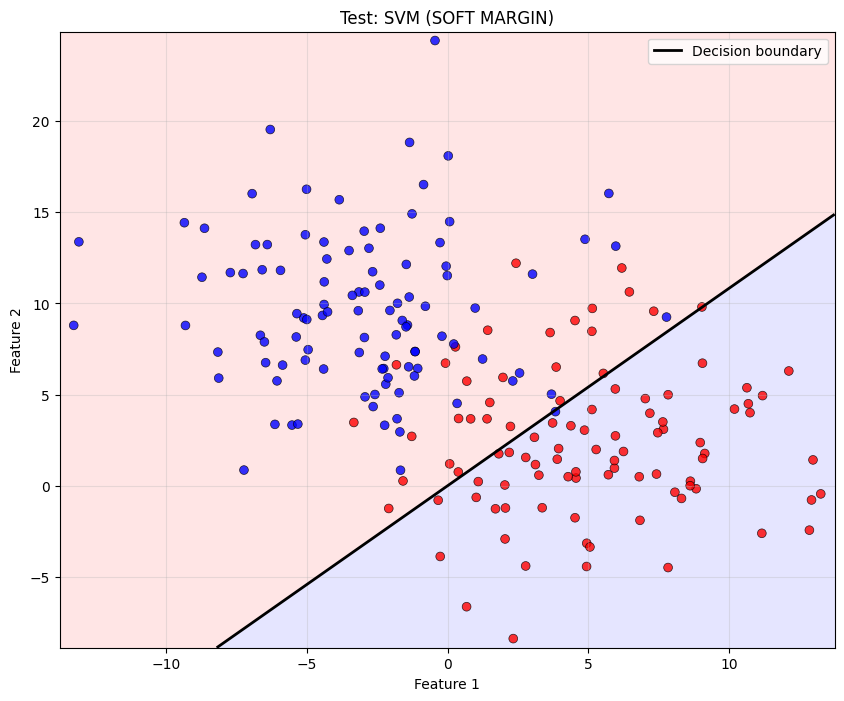

fit MB: 17.20909070968628
predict MB: 0.000118255615234375
Accuracy: 86.00%


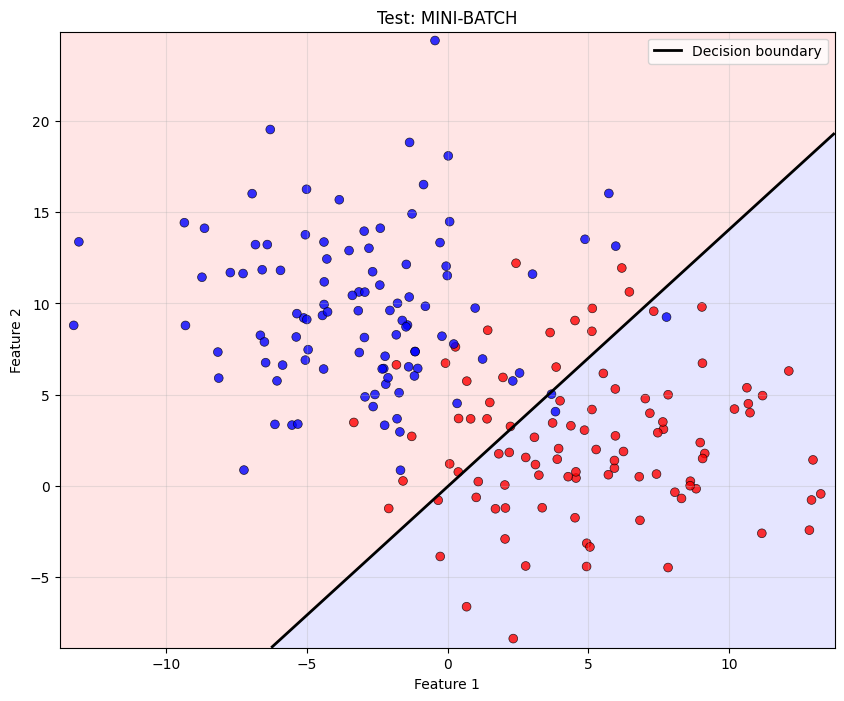

In [39]:
import time
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
#X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
#                       n_informative=2, n_clusters_per_class=1, random_state=42)
# Генерируем данные
X, y = make_blobs(n_samples=1000, centers=2, n_features=2, 
                  cluster_std=4, random_state=42)
y = np.where(y == 0, 0, 1)
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
# Обучаем + Предсказываем + Диагностика

"""sgdsvm = SOFT_SVM_SGD(C=1, learning_rate=0.001, max_iterations=50000)
start=time.time()
sgdsvm.fit(X_train, y_train)
print(f'fit SGD: {time.time()-start}')

start=time.time()
y_pred3 = sgdsvm.predict(X_test)
print(f'predict SGD: {time.time()-start}')
acc3 = accuracy_score(y_test, y_pred3)*100
print(f"Accuracy: {acc3:.2f}%")

plot_svm_boundary(sgdsvm, X_test, y_test, "SGD SVM")"""
    
softsvm = SOFT_SVM(C=0.001, learning_rate=1e-7, max_iterations=50000)
start=time.time()
softsvm.fit(X_train, y_train)
print(f'fit Soft: {time.time()-start}')

start=time.time()
y_pred4 = softsvm.predict(X_test)
print(f'predict Soft: {time.time()-start}')
acc4 = accuracy_score(y_test, y_pred4)*100
print(f"Accuracy: {acc4:.2f}%")

#plot_svm_boundary(softsvm, X_train, y_train, "Train: SVM (SOFT MARGIN)")
plot_svm_boundary(softsvm, X_test, y_test, "Test: SVM (SOFT MARGIN)")

mb_svm = MINI_BATCH_SVM(C=0.01,learning_rate=1e-7, max_iterations=50000, batch_size=32, tolerance=1e-7)
start=time.time()
mb_svm.fit(X_train, y_train)
print(f'fit MB: {time.time()-start}')

start=time.time()
y_pred5 = mb_svm.predict(X_test)
print(f'predict MB: {time.time()-start}')
acc5 = accuracy_score(y_test, y_pred5)*100
print(f"Accuracy: {acc5:.2f}%")

plot_svm_boundary(mb_svm, X_test, y_test, "Test: MINI-BATCH")

# Реализация Soft SVR (задача регресси)

In [4]:
class SoftSVR():
    
    def __init__(self, C=1, epsilon=1, learning_rate=0.1, tolerance=1e-12, max_iterations=10000):
        self.C = C
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations

    def fit(self, X,y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        prev_loss = np.inf
        loss_history = []
        
        for iter in range(1, self.max_iterations+1):
            pred = X @ self.w + self.b
            diff = pred - y
            abs_errors = np.abs(diff)
            positive_cutoff = np.maximum(abs_errors - self.epsilon, 0)
            fine = self.C * np.sum(positive_cutoff)
            margin = 1/2 * np.linalg.norm(self.w) **2 #(self.w @ self.w)
            loss = fine + margin
            loss_history.append(loss)

            #субградиент для Hinge loss
            s = np.sign(diff)
            s[np.abs(diff) <= self.epsilon] = 0
            
            dw1 = self.w.copy()
            dw2 = self.C * (s @ X)
            db = -self.C * np.sum(s)
            dw= dw1 - dw2

            alpha = self.learning_rate / np.sqrt(iter)
            self.w -= alpha * dw
            self.b -= alpha * db
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Сошлись на итерации {iter}")
                break
            prev_loss = loss

        
        return loss_history

    def predict(self, X):
        return X @ self.w + self.b

# Датасет + LOO

In [6]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Генерация данных для регрессии
X, y = make_regression(
    n_samples=300,           # количество объектов
    n_features=5,            # количество признаков
    n_informative=3,         # количество информативных признаков
    noise=10,                # шум (чем больше, тем разбросаннее)
    random_state=42
)

# Преобразуем в DataFrame
df_reg = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df_reg['target'] = y

print("Датасет для регрессии (make_regression):")
print(df_reg.head())
print(f"\nФорма: {df_reg.shape}")
print(f"Диапазон target: [{y.min():.2f}, {y.max():.2f}]")
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Датасет для регрессии (make_regression):
   feature_1  feature_2  feature_3  feature_4  feature_5      target
0   0.504047  -0.530258  -0.985726   0.955142  -0.062679   27.171911
1   0.374057   1.227669  -1.993736   0.833529   0.330880  -28.978799
2   0.610370  -0.020902   0.747294  -0.560181  -0.828995  -30.334935
3  -0.689188   1.735964   2.075261   0.197600   1.317394  135.888864
4   0.624120   0.628346   0.791663   1.158111  -1.214189  103.106899

Форма: (300, 6)
Диапазон target: [-277.32, 282.48]


In [23]:
def loo_svr(X, y, C, epsilon, learning_rate, max_iterations=500):
    """
    Leave-one-out cross validation для SVR
    Возвращает среднюю MSE
    """
    n_samples = len(X)
    total_mse = 0
    
    for i in range(n_samples):
        # Оставляем i-й объект как тестовый
        X_val = X[i:i+1]
        y_val = y[i]
        
        # Остальные — обучающие
        X_train_loo = np.delete(X, i, axis=0)
        y_train_loo = np.delete(y, i, axis=0)
        """
        # Обучаем SVR
        svr = SoftSVR(C=C, epsilon=epsilon, learning_rate=learning_rate, 
                      max_iterations=max_iterations)
        svr.fit(X_train_loo, y_train_loo)
        """
        from sklearn.svm import SVR
        model = SVR(C=C, epsilon=epsilon)
        model.fit(X_train_loo, y_train_loo)

        # Предсказание
        y_pred = model.predict(X_val)[0]
        
        # MSE для одного объекта
        total_mse += (y_val - y_pred) ** 2
    
    return total_mse / n_samples


# ============== Поиск оптимальных параметров ==============
print("="*60)
print("ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЛЯ SVR (LOO)")
print("="*60)

# Диапазоны параметров
C_values = [1, 10, 100, 200, 150]
epsilon_values = [0.01, 0.05, 0.1, 0.5, 1.0,2 , 5, 10, 50, 25, 100]
lr_values = [0.0001, 0.0005, 0.001, 0.005, 0.01]

best_mse = np.inf
best_params = {'C': None, 'epsilon': None, 'learning_rate': None}

for C in C_values:
    for epsilon in epsilon_values:
        #for lr in lr_values:
            mse = loo_svr(X_train, y_train, C, epsilon, lr, max_iterations=300)
            print(f"C={C}, eps={epsilon}, lr={lr}: MSE={mse:.4f}")
            
            if mse < best_mse:
                best_mse = mse
                best_params['C'] = C
                best_params['epsilon'] = epsilon
                best_params['learning_rate'] = lr

print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ")
print("="*60)
print(f"C_opt = {best_params['C']}")
print(f"eps_opt = {best_params['epsilon']}")
print(f"lr_opt = {best_params['learning_rate']}")
print(f"Лучшая MSE (LOO): {best_mse:.4f}")

# ============== Обучение с оптимальными параметрами ==============
C_opt = best_params['C']
eps_opt = best_params['epsilon']
lr_opt = best_params['learning_rate']

ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЛЯ SVR (LOO)
C=1, eps=0.01, lr=0.01: MSE=8684.2062
C=1, eps=0.05, lr=0.01: MSE=8689.5756
C=1, eps=0.1, lr=0.01: MSE=8696.5087
C=1, eps=0.5, lr=0.01: MSE=8729.2137
C=1, eps=1.0, lr=0.01: MSE=8723.6610
C=1, eps=2, lr=0.01: MSE=8673.5146
C=1, eps=5, lr=0.01: MSE=8693.7316
C=1, eps=10, lr=0.01: MSE=8838.8585
C=1, eps=50, lr=0.01: MSE=9076.4962
C=1, eps=25, lr=0.01: MSE=8879.0834
C=1, eps=100, lr=0.01: MSE=9757.0298
C=10, eps=0.01, lr=0.01: MSE=2497.1540
C=10, eps=0.05, lr=0.01: MSE=2498.2230
C=10, eps=0.1, lr=0.01: MSE=2499.6863
C=10, eps=0.5, lr=0.01: MSE=2507.2429
C=10, eps=1.0, lr=0.01: MSE=2500.2303
C=10, eps=2, lr=0.01: MSE=2500.3551
C=10, eps=5, lr=0.01: MSE=2495.5039
C=10, eps=10, lr=0.01: MSE=2584.8859
C=10, eps=50, lr=0.01: MSE=3839.4269
C=10, eps=25, lr=0.01: MSE=2879.1115
C=10, eps=100, lr=0.01: MSE=5765.8965
C=100, eps=0.01, lr=0.01: MSE=493.1291
C=100, eps=0.05, lr=0.01: MSE=493.9263
C=100, eps=0.1, lr=0.01: MSE=494.7730
C=100, eps=0.5, lr=0.01: M

# Тесты + сравнение с scilearn

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from time import time
C_opt = 0.1
eps_opt = 1.0
lr_opt = 0.0001

svr = SoftSVR(C=C_opt, epsilon=eps_opt, learning_rate=lr_opt, max_iterations=1000)
start1=time()
svr.fit(X_train, y_train)
print(f"fit: {time()-start1}")
start2=time()
pred = svr.predict(X_test)
print(f"predict: {time()-start2}")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (softsvr)")
print("="*60)
print(f"MSE: {mean_squared_error(y_test, pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.4f}")
print(f"R²: {r2_score(y_test, pred):.4f}")
print("\nРазница (pred - y_test):")
print(pred-y_test)

from sklearn.svm import SVR
model = SVR(C=100)
start1=time()
model.fit(X_train, y_train)
print(f"fit: {time()-start1}")
y_pred = model.predict(X_test)
print(f"predict: {time()-start2}")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (scilearn)")
print("="*60)
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print("\nРазница (y_pred - y_test):")
print(y_pred-y_test)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
start1 = time()
model.fit(X_train, y_train)
print(f"fit: {time() - start1:.4f} сек")
start2 = time()
y_pred1 = model.predict(X_test)
print(f"predict: {time() - start2:.4f} сек")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (LinearRegression)")
print("="*60)
print(f"MSE: {mean_squared_error(y_test, y_pred1):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred1):.4f}")
print(f"R²: {r2_score(y_test, y_pred1):.4f}")

print(y_pred1 - y_test)

fit: 0.03779911994934082
predict: 0.0002646446228027344

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (softsvr)
MSE: 1.1525
MAE: 0.8808
R²: -0.1369

Разница (pred - y_test):
[ 0.4391052   0.39401317 -0.04853726 -1.25993676 -1.42832391  0.74227217
 -0.80371554  0.86347946 -2.11717346 -0.26375599 -0.06782426  1.80743171
  1.70478217 -0.93554407  1.28398861  1.21143741 -0.52207697 -0.51369494
  0.80849474  0.41778056  0.04675012  0.45254859 -0.03058947  0.08405701
  1.87574676 -1.51846359  0.35811188 -0.15573391 -0.06477562 -0.07238832
 -0.00738891  0.3999549   0.80998888  1.09596398 -0.33594968 -1.61887697
 -0.02450785  1.83279242 -0.81829916 -0.65180185 -1.59565719 -1.12941446
 -0.45501253  1.9603104  -0.01704989  0.42450795 -1.48950131 -1.47071655
 -0.31981003 -0.81125503 -0.53824697 -0.54413557 -1.42077696  1.48297447
 -1.02072252 -0.14873029 -1.150062   -1.23242585  0.81684461  1.57415233
 -0.40882712  0.514492   -2.06112097  1.49459495 -1.31611845  1.41789321
 -0.3001456   0.43348486 -0.83409512 

# Кусочно-линейная функция потерь визуально (пояснение для субградиента)

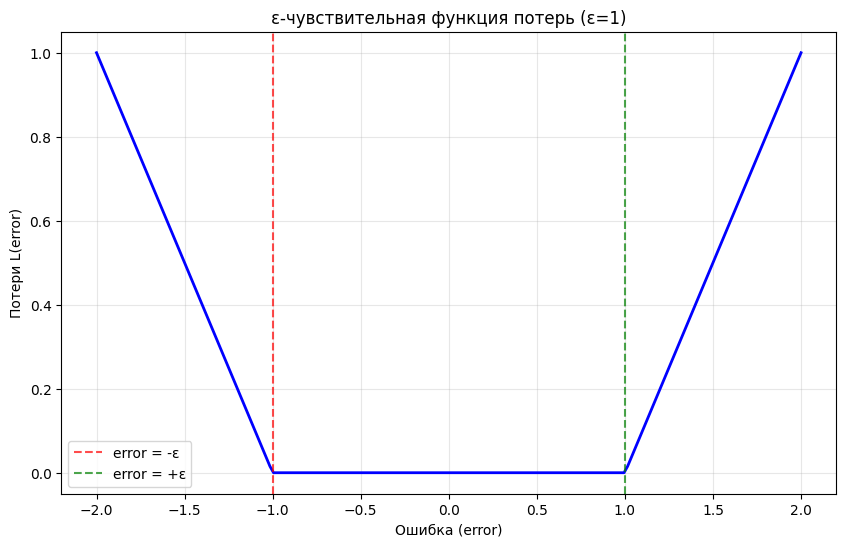

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def loss(error, epsilon=1):
    return np.maximum(0, np.abs(error) - epsilon)

error = np.linspace(-2, 2, 200)
loss_values = loss(error)

plt.figure(figsize=(10, 6))
plt.plot(error, loss_values, 'b-', linewidth=2)
plt.axvline(x=-1, color='r', linestyle='--', alpha=0.7, label='error = -ε')
plt.axvline(x=1, color='g', linestyle='--', alpha=0.7, label='error = +ε')
plt.grid(True, alpha=0.3)
plt.xlabel('Ошибка (error)')
plt.ylabel('Потери L(error)')
plt.title('ε-чувствительная функция потерь (ε=1)')
plt.legend()
plt.show()

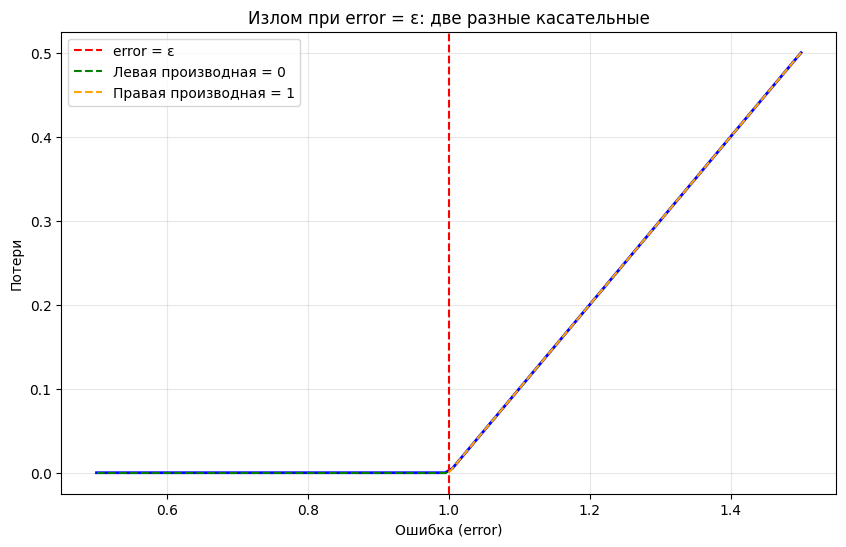

In [78]:
error = np.linspace(0.5, 1.5, 100)
loss_vals = np.maximum(0, error - 1)

plt.figure(figsize=(10, 6))
plt.plot(error, loss_vals, 'b-', linewidth=2)
plt.axvline(x=1, color='r', linestyle='--', label='error = ε')

# Левая касательная (наклон 0)
x_left = np.linspace(0.5, 1, 10)
y_left = np.zeros_like(x_left)
plt.plot(x_left, y_left, 'g--', linewidth=1.5, label='Левая производная = 0')

# Правая касательная (наклон 1)
x_right = np.linspace(1, 1.5, 10)
y_right = x_right - 1
plt.plot(x_right, y_right, 'orange', linestyle='--', linewidth=1.5, label='Правая производная = 1')

plt.xlabel('Ошибка (error)')
plt.ylabel('Потери')
plt.title('Излом при error = ε: две разные касательные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

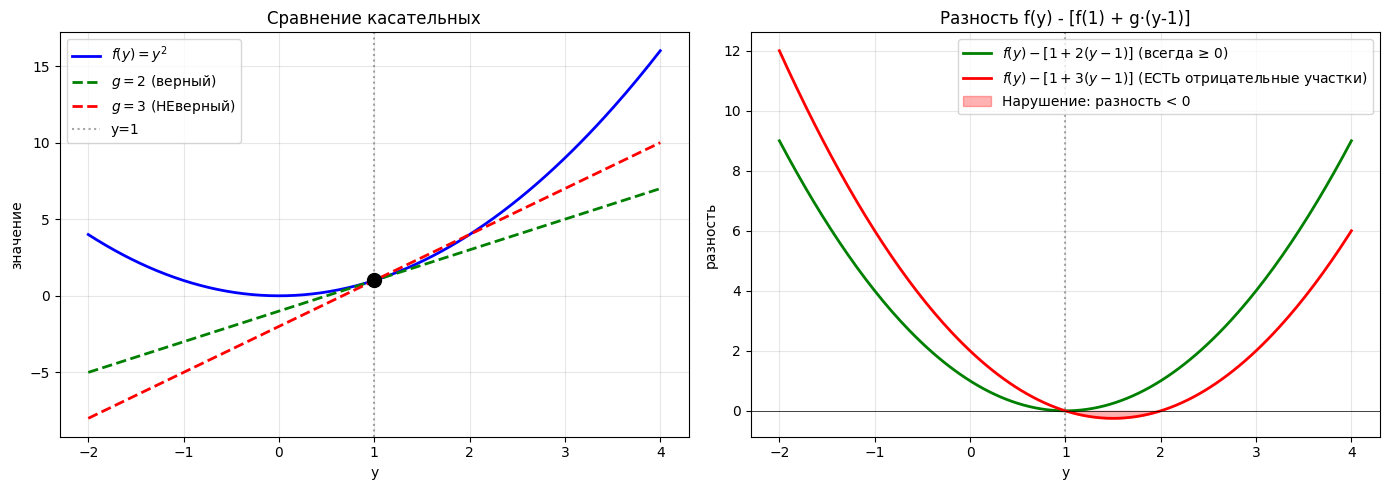

ПРОВЕРКА НЕРАВЕНСТВА f(y) ≥ f(1) + g·(y-1)

--- g = 2 ---
  y=0: 0.00 ≥ -1.00 → True ✅
  y=0.5: 0.25 ≥ 0.00 → True ✅
  y=1: 1.00 ≥ 1.00 → True ✅
  y=1.5: 2.25 ≥ 2.00 → True ✅
  y=2: 4.00 ≥ 3.00 → True ✅

--- g = 3 ---
  y=0: 0.00 ≥ -2.00 → True ✅
  y=0.5: 0.25 ≥ -0.50 → True ✅
  y=1: 1.00 ≥ 1.00 → True ✅
  y=1.5: 2.25 ≥ 2.50 → False ❌ НАРУШЕНИЕ!
  y=2: 4.00 ≥ 4.00 → True ✅


In [85]:
import numpy as np
import matplotlib.pyplot as plt

y = np.linspace(-2, 4, 200)

# Функция
f_y = y**2

# Правильный субградиент (g = 2)
correct_tangent = 1 + 2 * (y - 1)

# НЕправильный (g = 3) — завышенный наклон
wrong_tangent = 1 + 3 * (y - 1)

# Разницы
diff_correct = f_y - correct_tangent
diff_wrong = f_y - wrong_tangent

plt.figure(figsize=(14, 5))

# График 1: Сравнение функций
plt.subplot(1, 2, 1)
plt.plot(y, f_y, 'b-', linewidth=2, label='$f(y) = y^2$')
plt.plot(y, correct_tangent, 'g--', linewidth=2, label='$g=2$ (верный)')
plt.plot(y, wrong_tangent, 'r--', linewidth=2, label='$g=3$ (НЕверный)')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7, label='y=1')
plt.scatter([1], [1], color='black', s=100, zorder=5)
plt.xlabel('y')
plt.ylabel('значение')
plt.title('Сравнение касательных')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Разности
plt.subplot(1, 2, 2)
plt.plot(y, diff_correct, 'g-', linewidth=2, label='$f(y) - [1+2(y-1)]$ (всегда ≥ 0)')
plt.plot(y, diff_wrong, 'r-', linewidth=2, label='$f(y) - [1+3(y-1)]$ (ЕСТЬ отрицательные участки)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.fill_between(y, 0, diff_wrong, where=(diff_wrong < 0), color='red', alpha=0.3, label='Нарушение: разность < 0')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('y')
plt.ylabel('разность')
plt.title('Разность f(y) - [f(1) + g·(y-1)]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Проверка конкретных точек
print("="*60)
print("ПРОВЕРКА НЕРАВЕНСТВА f(y) ≥ f(1) + g·(y-1)")
print("="*60)

for g in [2, 3]:
    print(f"\n--- g = {g} ---")
    for y_test in [0, 0.5, 1, 1.5, 2]:
        left = y_test**2
        right = 1 + g * (y_test - 1)
        satisfied = left >= right
        status = "✅" if satisfied else "❌ НАРУШЕНИЕ!"
        print(f"  y={y_test}: {left:.2f} ≥ {right:.2f} → {satisfied} {status}")